<a href="https://colab.research.google.com/github/nagaraj1696/DLNN_exps_R24EV028/blob/main/exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2164s 13us/step


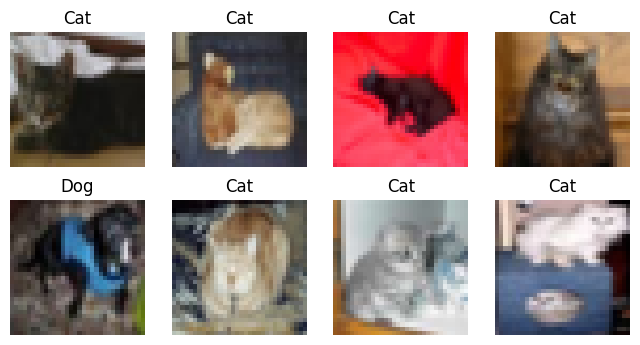

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5698 - loss: 0.6772 - val_accuracy: 0.6280 - val_loss: 0.6598
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6478 - loss: 0.6360 - val_accuracy: 0.6625 - val_loss: 0.6156
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6900 - loss: 0.5886 - val_accuracy: 0.6870 - val_loss: 0.5796
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7185 - loss: 0.5519 - val_accuracy: 0.7115 - val_loss: 0.5619
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7370 - loss: 0.5271 - val_accuracy: 0.7235 - val_loss: 0.5469
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7513 - loss: 0.5056 - val_accuracy: 0.7245 - val_loss: 0.5519
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7650 - loss: 0.4823 - val_accuracy: 0.7240 - val_loss: 0.5483
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7794 - loss: 0.4609 - val_accuracy: 0

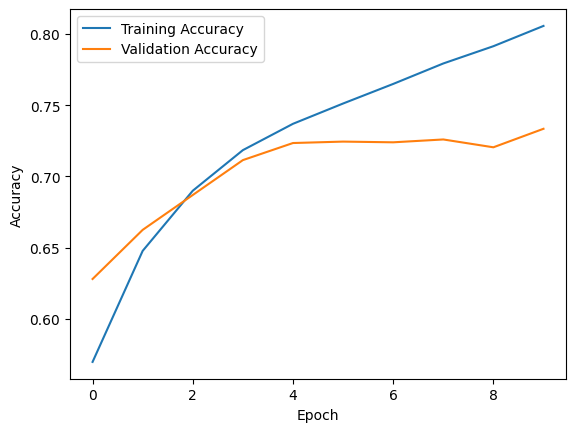

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 classes:
# 3 = Cat, 5 = Dog

# Select only cats and dogs
train_mask = (y_train.flatten() == 3) | (y_train.flatten() == 5)
test_mask = (y_test.flatten() == 3) | (y_test.flatten() == 5)

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]

# Convert labels: Cat = 0, Dog = 1
y_train = (y_train.flatten() == 5).astype(int)
y_test = (y_test.flatten() == 5).astype(int)

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Display sample images
plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title("Dog" if y_train[i] == 1 else "Cat")
    plt.axis("off")

plt.show()

# Create CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Binary output
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

# Test
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


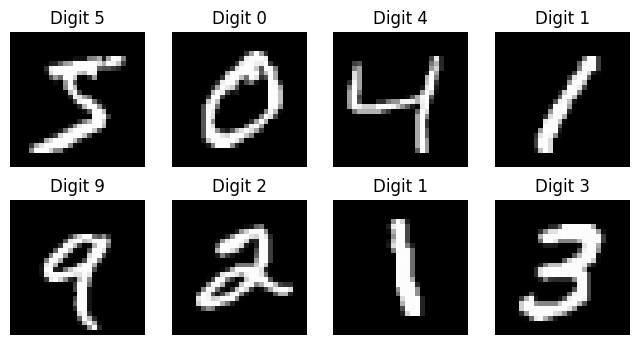

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9145 - loss: 0.2755 - val_accuracy: 0.9771 - val_loss: 0.0776
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9727 - loss: 0.0938 - val_accuracy: 0.9849 - val_loss: 0.0497
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9795 - loss: 0.0683 - val_accuracy: 0.9894 - val_loss: 0.0391
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9840 - loss: 0.0552 - val_accuracy: 0.9886 - val_loss: 0.0407
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9861 - loss: 0.0453 - val_accuracy: 0.9881 - val_loss: 0.0415
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9878 - loss: 0.0402 - val_accuracy: 0.9914 - val_loss: 0.0325
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9892 - loss: 0.0342 - val_accuracy: 0.9906 - val_loss: 0.0347
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9905 - loss: 0.0319 - val_accuracy: 0.

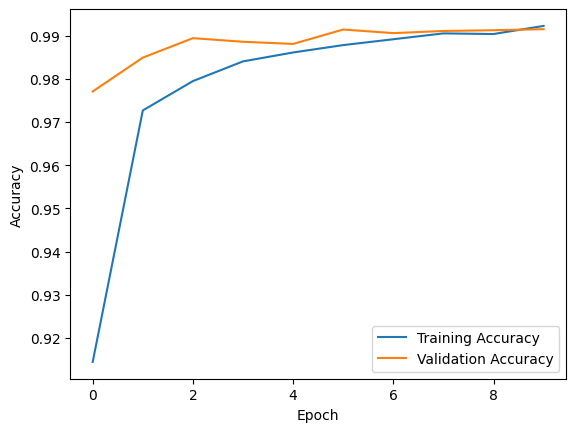

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Display sample images
plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Digit " + str(y_train[i]))
    plt.axis("off")

plt.show()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # 10 classes: digits 0-9
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

# Test
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()